In [64]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
from statistics import mode
import matplotlib.pyplot as plt
import os, pickle, IPython

from sklearn import datasets, preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mlxtend.data import mnist_data
from keras.datasets import mnist
from collections import Counter

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

from skimage import io, transform, color
from skimage.feature import graycomatrix , graycoprops

%matplotlib widget

def get_current_directory():
    try:
        
        directory = os.path.dirname(os.path.abspath(__file__))

    except:
        
        ip = IPython.get_ipython()
        directory = None
        if '__vsc_ipynb_file__' in ip.user_ns:
            directory = os.path.dirname(ip.user_ns['__vsc_ipynb_file__'])
        
    return directory 


def salvar(a):
    
    script_dir = get_current_directory()
    
    dados_dir = os.path.join(script_dir, 'dados')
    
    os.makedirs(dados_dir, exist_ok=True)
    
    file_path = os.path.join(dados_dir, f'{a}.pickle')
    
    with open(file_path, 'wb') as f:
        pickle.dump(eval(a), f)

def abrir(a):
    
    script_dir = get_current_directory()
    
    file_path = os.path.join(script_dir, 'dados', f'{a}.pickle')
    
    with open(file_path, 'rb') as f:
        return pickle.load(f)
    
def salvar_obj(obj, filename):
    script_dir = get_current_directory()
    dados_dir = os.path.join(script_dir, 'dados')
    os.makedirs(dados_dir, exist_ok=True)
    
    file_path = os.path.join(dados_dir, f'{filename}.pickle')
    
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f)

In [ ]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

In [9]:
test_1 = train_X[0]

print(f"Shape image: {test_1.shape}")

Shape image: (28, 28)


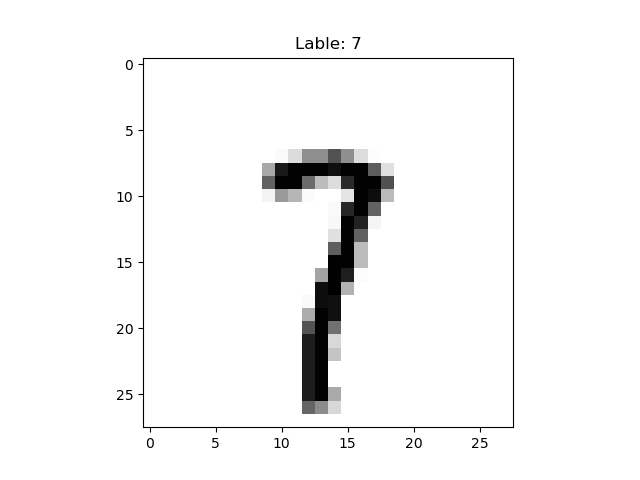

In [36]:
def plot_digit(x, cmap = 'Greys'):
    img = train_X[x]
    plt.figure()
    plt.imshow(img, cmap = cmap)
    plt.title('Lable: %d' % train_y[x])
    plt.show()   
    
    
plot_digit(1832)

In [28]:
train_featurevectors_64 = abrir('train_featurevectors_64')

test_featurevectors_64 = abrir('test_featurevectors_64')

train_featurevectors_64.shape, test_featurevectors_64.shape

((60000, 64), (10000, 64))

In [ ]:
# Com M = 60000 e N = 64, mas queremos potencias de 2. 

M_original = train_featurevectors_64.shape[0] # 60000
N = train_featurevectors_64.shape[1] # 64
m = 16
M_target = 2**m # 65536
n = int(np.log2(N)) # 6 -> N=64 é potência de 2

diff_adicionar = M_target - M_original # 5536

if diff_adicionar > 0:
    train_featurevectors_64 = np.concatenate((train_featurevectors_64, train_featurevectors_64[:diff_adicionar]), axis=0)
    
j_reg_beta = QuantumRegister(m, name='j')    
i_reg_beta = QuantumRegister(n, name='i') 
anc_1_reg_beta = QuantumRegister(1, name='anc_1')
anc_2_reg_beta = QuantumRegister(1, name='anc_2')

beta_0_qc = QuantumCircuit(j_reg_beta, i_reg_beta, anc_1_reg_beta, anc_2_reg_beta, name='beta_0')

beta_0_qc.h(j_reg_beta)      
beta_0_qc.h(i_reg_beta) 

i_reg_alpha = QuantumRegister(n, name='i') 
anc_1_reg_alpha = QuantumRegister(1, name='anc_1')
anc_2_reg_alpha = QuantumRegister(1, name='anc_2')

alpha_0_qc = QuantumCircuit(i_reg_alpha, anc_1_reg_alpha, anc_2_reg_alpha, name='alpha_0')
     
alpha_0_qc.h(i_reg_alpha) 

if False: 
    
    print(beta_0_qc.draw(output='mpl'))
    print(alpha_0_qc.draw(output='mpl'))

In [47]:
beta_0_qc.num_qubits

24

In [62]:
alpha_estado = abrir('alpha_N64')
beta_estado = abrir('beta_M65536_N64')

vetor_de_teste = 0 
alpha_estado_selecionado = alpha_estado[vetor_de_teste]

m = 16
n = 6
num_qubits_beta = m + n + 2 # 24
num_qubits_alpha = n + 2    # 8
num_qubits_total = num_qubits_beta + num_qubits_alpha + 1 # 33


beta_qubits = list(range(num_qubits_beta))              # Qubits 0 a 23
alpha_qubits = list(range(num_qubits_beta, num_qubits_beta + num_qubits_alpha)) # Qubits 24 a 31
swap_ancilla_qubit = num_qubits_total - 1     

beta_feature_qubits_indices = list(range(m, m + n + 2))

qc = QuantumCircuit(num_qubits_total, 1, name="QKNN_SWAP_Test")

qc.initialize(beta_estado, beta_qubits)
print("Estado beta inicializado")

qc.initialize(alpha_estado_selecionado, alpha_qubits)
print("Estado alpha inicializado")

qc.barrier()

qc.h(swap_ancilla_qubit)

for k in range(num_qubits_alpha):
    
    alpha_q = alpha_qubits[k]
    
    beta_feature_q = beta_qubits[m + k]
    qc.cswap(swap_ancilla_qubit, alpha_q, beta_feature_q)
    
qc.h(swap_ancilla_qubit)

qc.barrier()

qc.measure(swap_ancilla_qubit, 0)

if False: 

    print(qc.draw(output='mpl'))

Estado beta inicializado
Estado alpha inicializado


Figure(2061.76x2876.22)


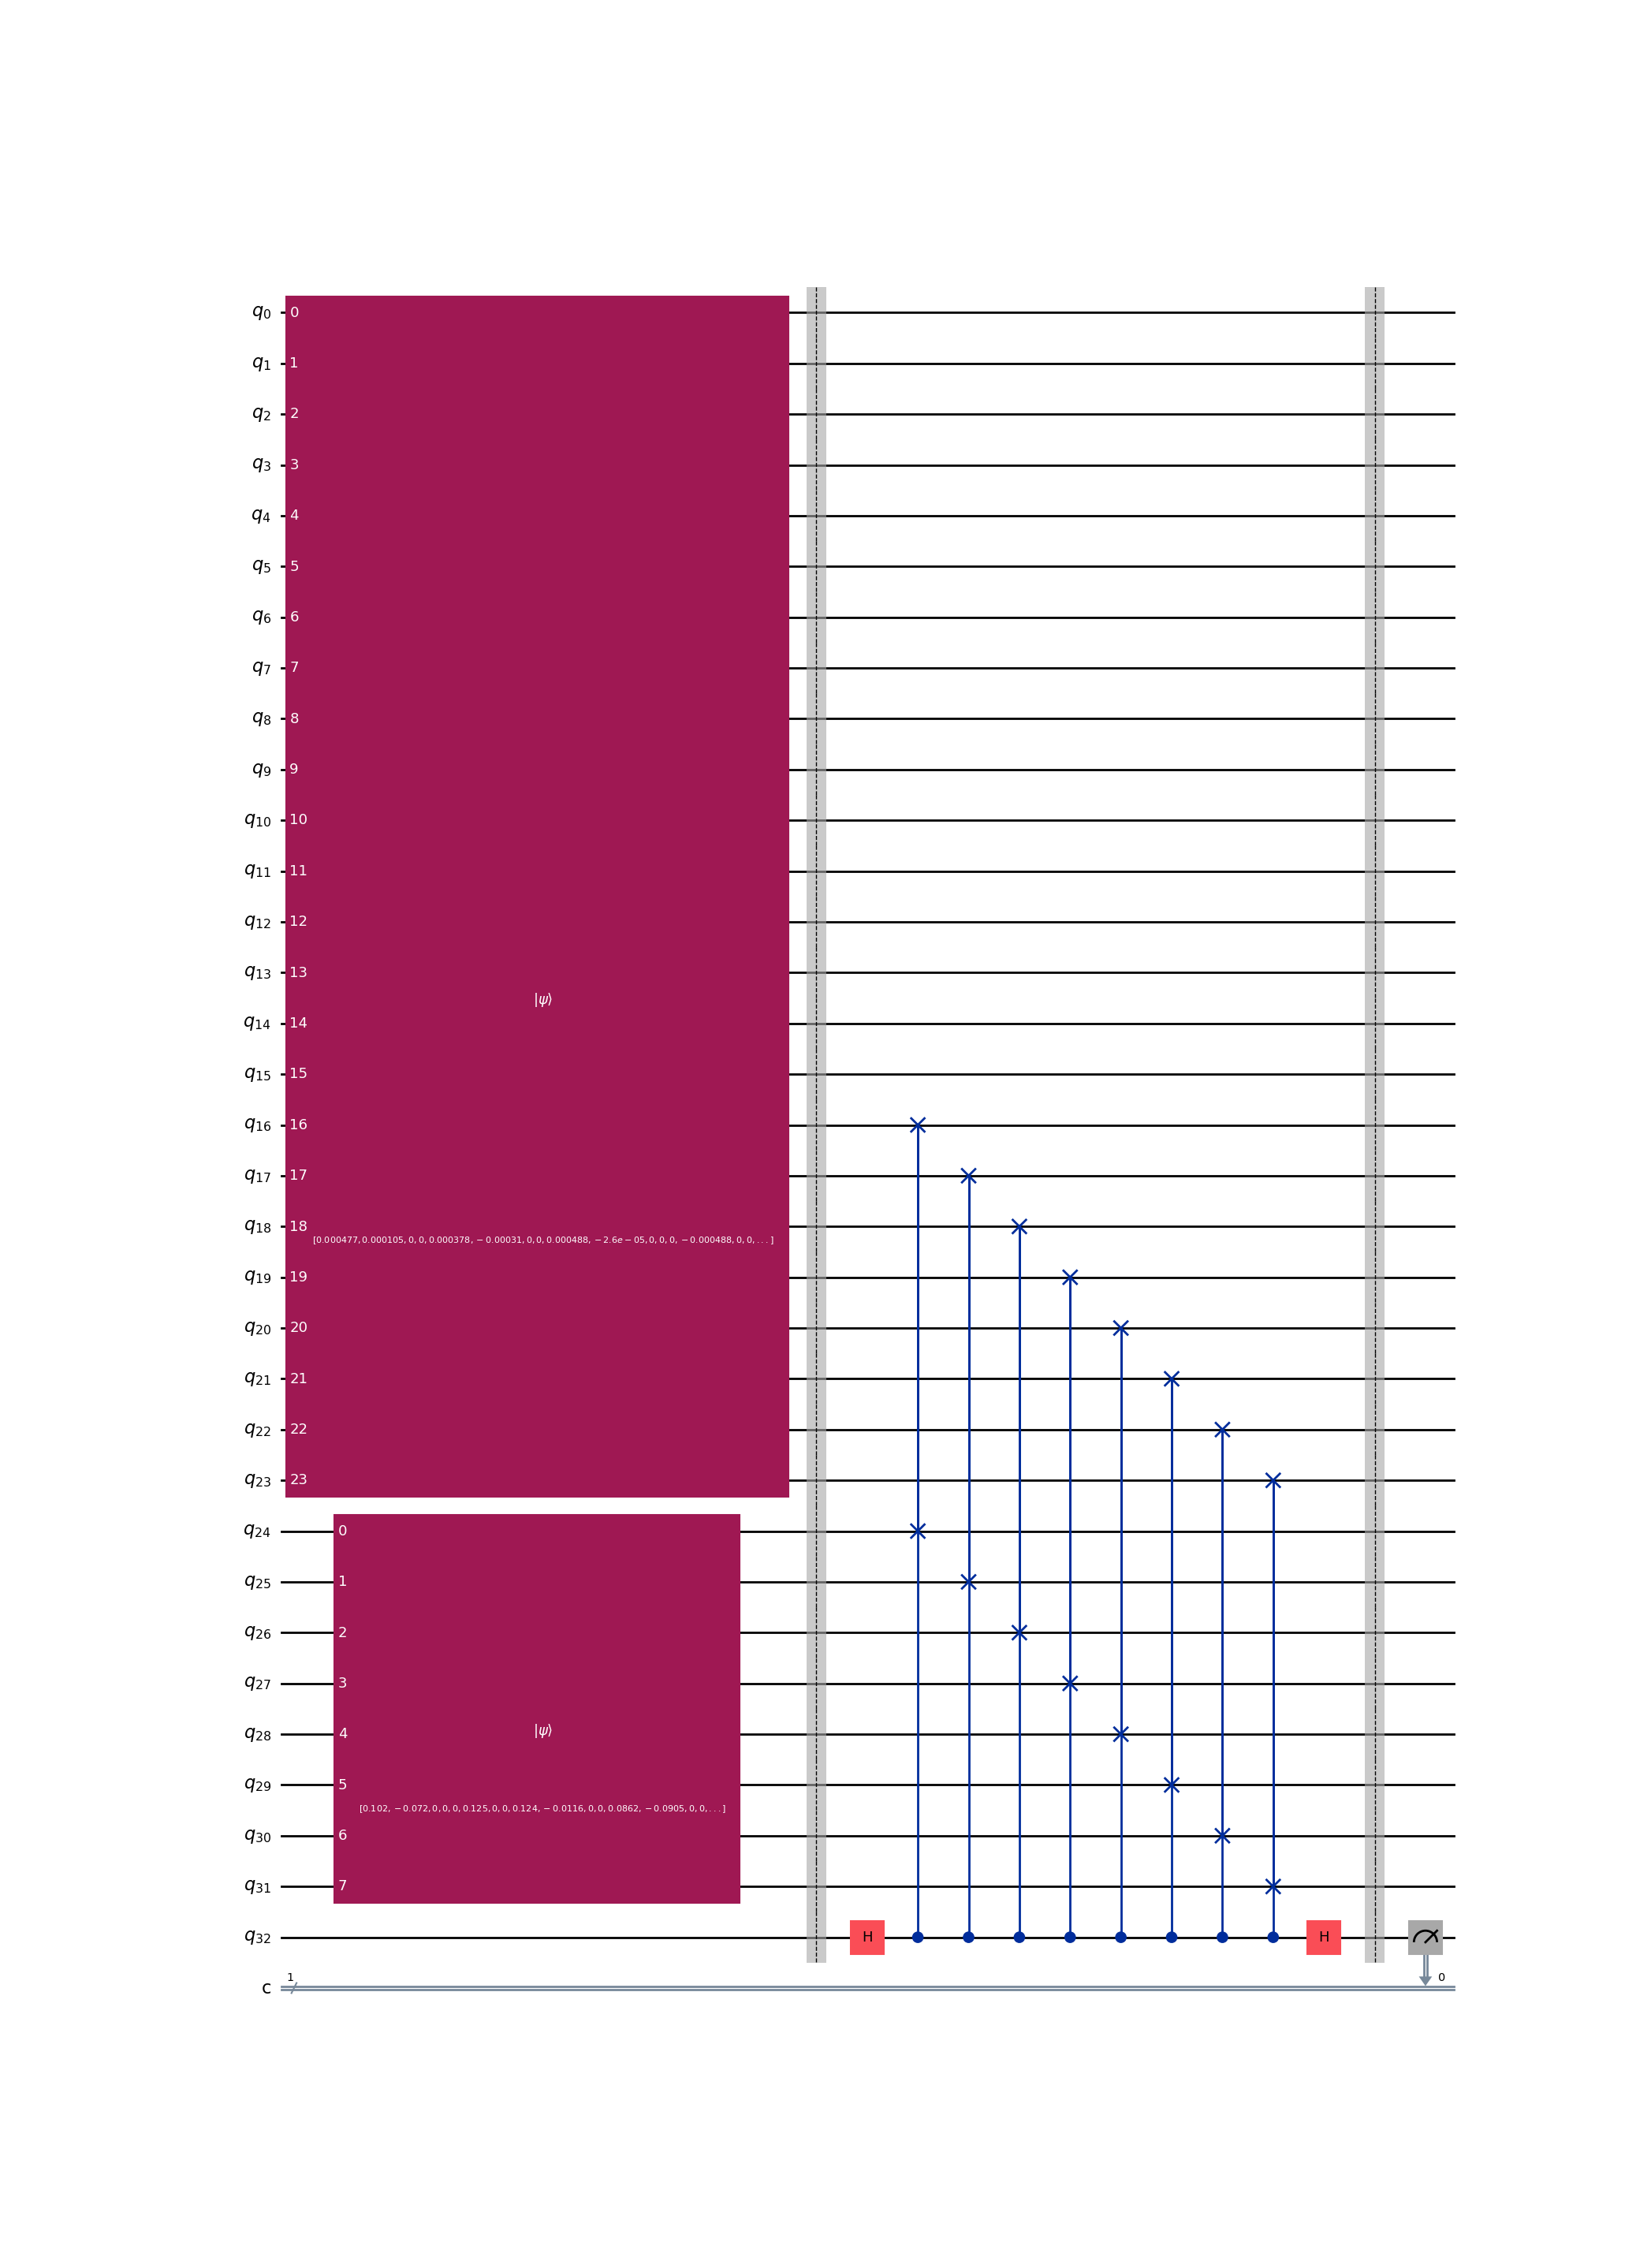

In [63]:
print(qc.draw(output='mpl'))

O circuito é muito grande, de maneira que não é possível simular o circuito inteiro. Sendo assim, alteraremos os nossos parametros de simulação.

In [ ]:
if False:    
    M_final = 2048 # M = 2^11
    N_final = 16   # N = 2^4

    (X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

    X_train_full_flat = X_train_full.reshape(X_train_full.shape[0], -1).astype('float32') / 255.0
    X_test_full_flat = X_test_full.reshape(X_test_full.shape[0], -1).astype('float32')

    def distribuicao_equiprovavel(X_tot, y_tot, M):
        
        labels, counts = np.unique(y_tot, return_counts=True)
        n_class = len(labels)
        samples_p_class = M // n_class
        r = M % n_class

        subset_indices = [] 

        np.random.seed(42) 

        all_original_indices = np.arange(len(y_tot)) 

        for i, label in enumerate(labels):
            
            class_mask = (y_tot == label)
            original_indices_for_class = all_original_indices[class_mask] 

            n_samples_class = samples_p_class + (1 if i < r else 0)
            
            n_samples_class = min(n_samples_class, len(original_indices_for_class))

            selec = np.random.choice(original_indices_for_class, size=n_samples_class, replace=False)

            subset_indices.extend(selec) # AGORA FUNCIONA!

        np.random.shuffle(subset_indices)
        final_indices = subset_indices[:M]

        return X_tot[final_indices], y_tot[final_indices]

    X_train_M, y_train_M = distribuicao_equiprovavel(X_train_full_flat, y_train_full, M_final)

    print(f"Shape: {X_train_M.shape}")
    print(f"Distribuição M={M_final}: {sorted(Counter(y_train_M).items())}")



Shape: (2048, 784)
Distribuição M=2048: [(0, 205), (1, 205), (2, 205), (3, 205), (4, 205), (5, 205), (6, 205), (7, 205), (8, 204), (9, 204)]


In [ ]:
if False:
    pca = PCA(n_components=N_final, random_state=42)

    pca.fit(X_train_M)

    train_pca = pca.transform(X_train_M)

    test_pca = pca.transform(X_test_full_flat)

    #--

    scaler = StandardScaler()
    scaler.fit(train_pca)

    train_scaled = scaler.transform(train_pca)
    test_scaled = scaler.transform(test_pca)

    salvar_obj(train_scaled, 'train_featurevectors_16')
    salvar_obj(test_scaled, 'test_featurevectors_16')


In [ ]:
train_featurevectors_16 = abrir('train_featurevectors_16')
test_featurevectors_16 = abrir('test_featurevectors_16')


In [77]:
alpha_estado = abrir('alpha_N16')
beta_estado = abrir('beta_M2048_N16')

vetor_de_teste = 0 
alpha_estado_selecionado = alpha_estado[vetor_de_teste]

m = 11
n = 4
num_qubits_beta = m + n + 1 # 16
num_qubits_alpha = n + 1    # 5
num_qubits_swap_ancilla = 1
num_qubits_total = num_qubits_beta + num_qubits_alpha + num_qubits_swap_ancilla


beta_q = list(range(num_qubits_beta))              
alpha_q = list(range(num_qubits_beta, num_qubits_beta + num_qubits_alpha))
swap_anc_q = num_qubits_total - 1  

beta_feature_value_q_indices = list(range(m, m + n + 1))

qr = QuantumRegister(num_qubits_total, name='q')
cr = ClassicalRegister(1, name="c_swap")
qc = QuantumCircuit(qr, cr, name="QKNN_SWAP_Test_Reduced")

qc.initialize(beta_estado, beta_q)
qc.initialize(alpha_estado_selecionado, alpha_q)

qc.barrier()

qc.h(swap_anc_q)

for k in range(num_qubits_alpha): 

    alpha_qubit_k = alpha_q[k]    

    beta_qubit_k = beta_q[m + k]  

    qc.cswap(swap_anc_q, alpha_qubit_k, beta_qubit_k)
    
qc.h(swap_anc_q)

qc.barrier()

qc.measure(swap_anc_q, cr[0])

if False: 

    print(qc.draw(output='mpl'))

Figure(2112.03x1956.5)


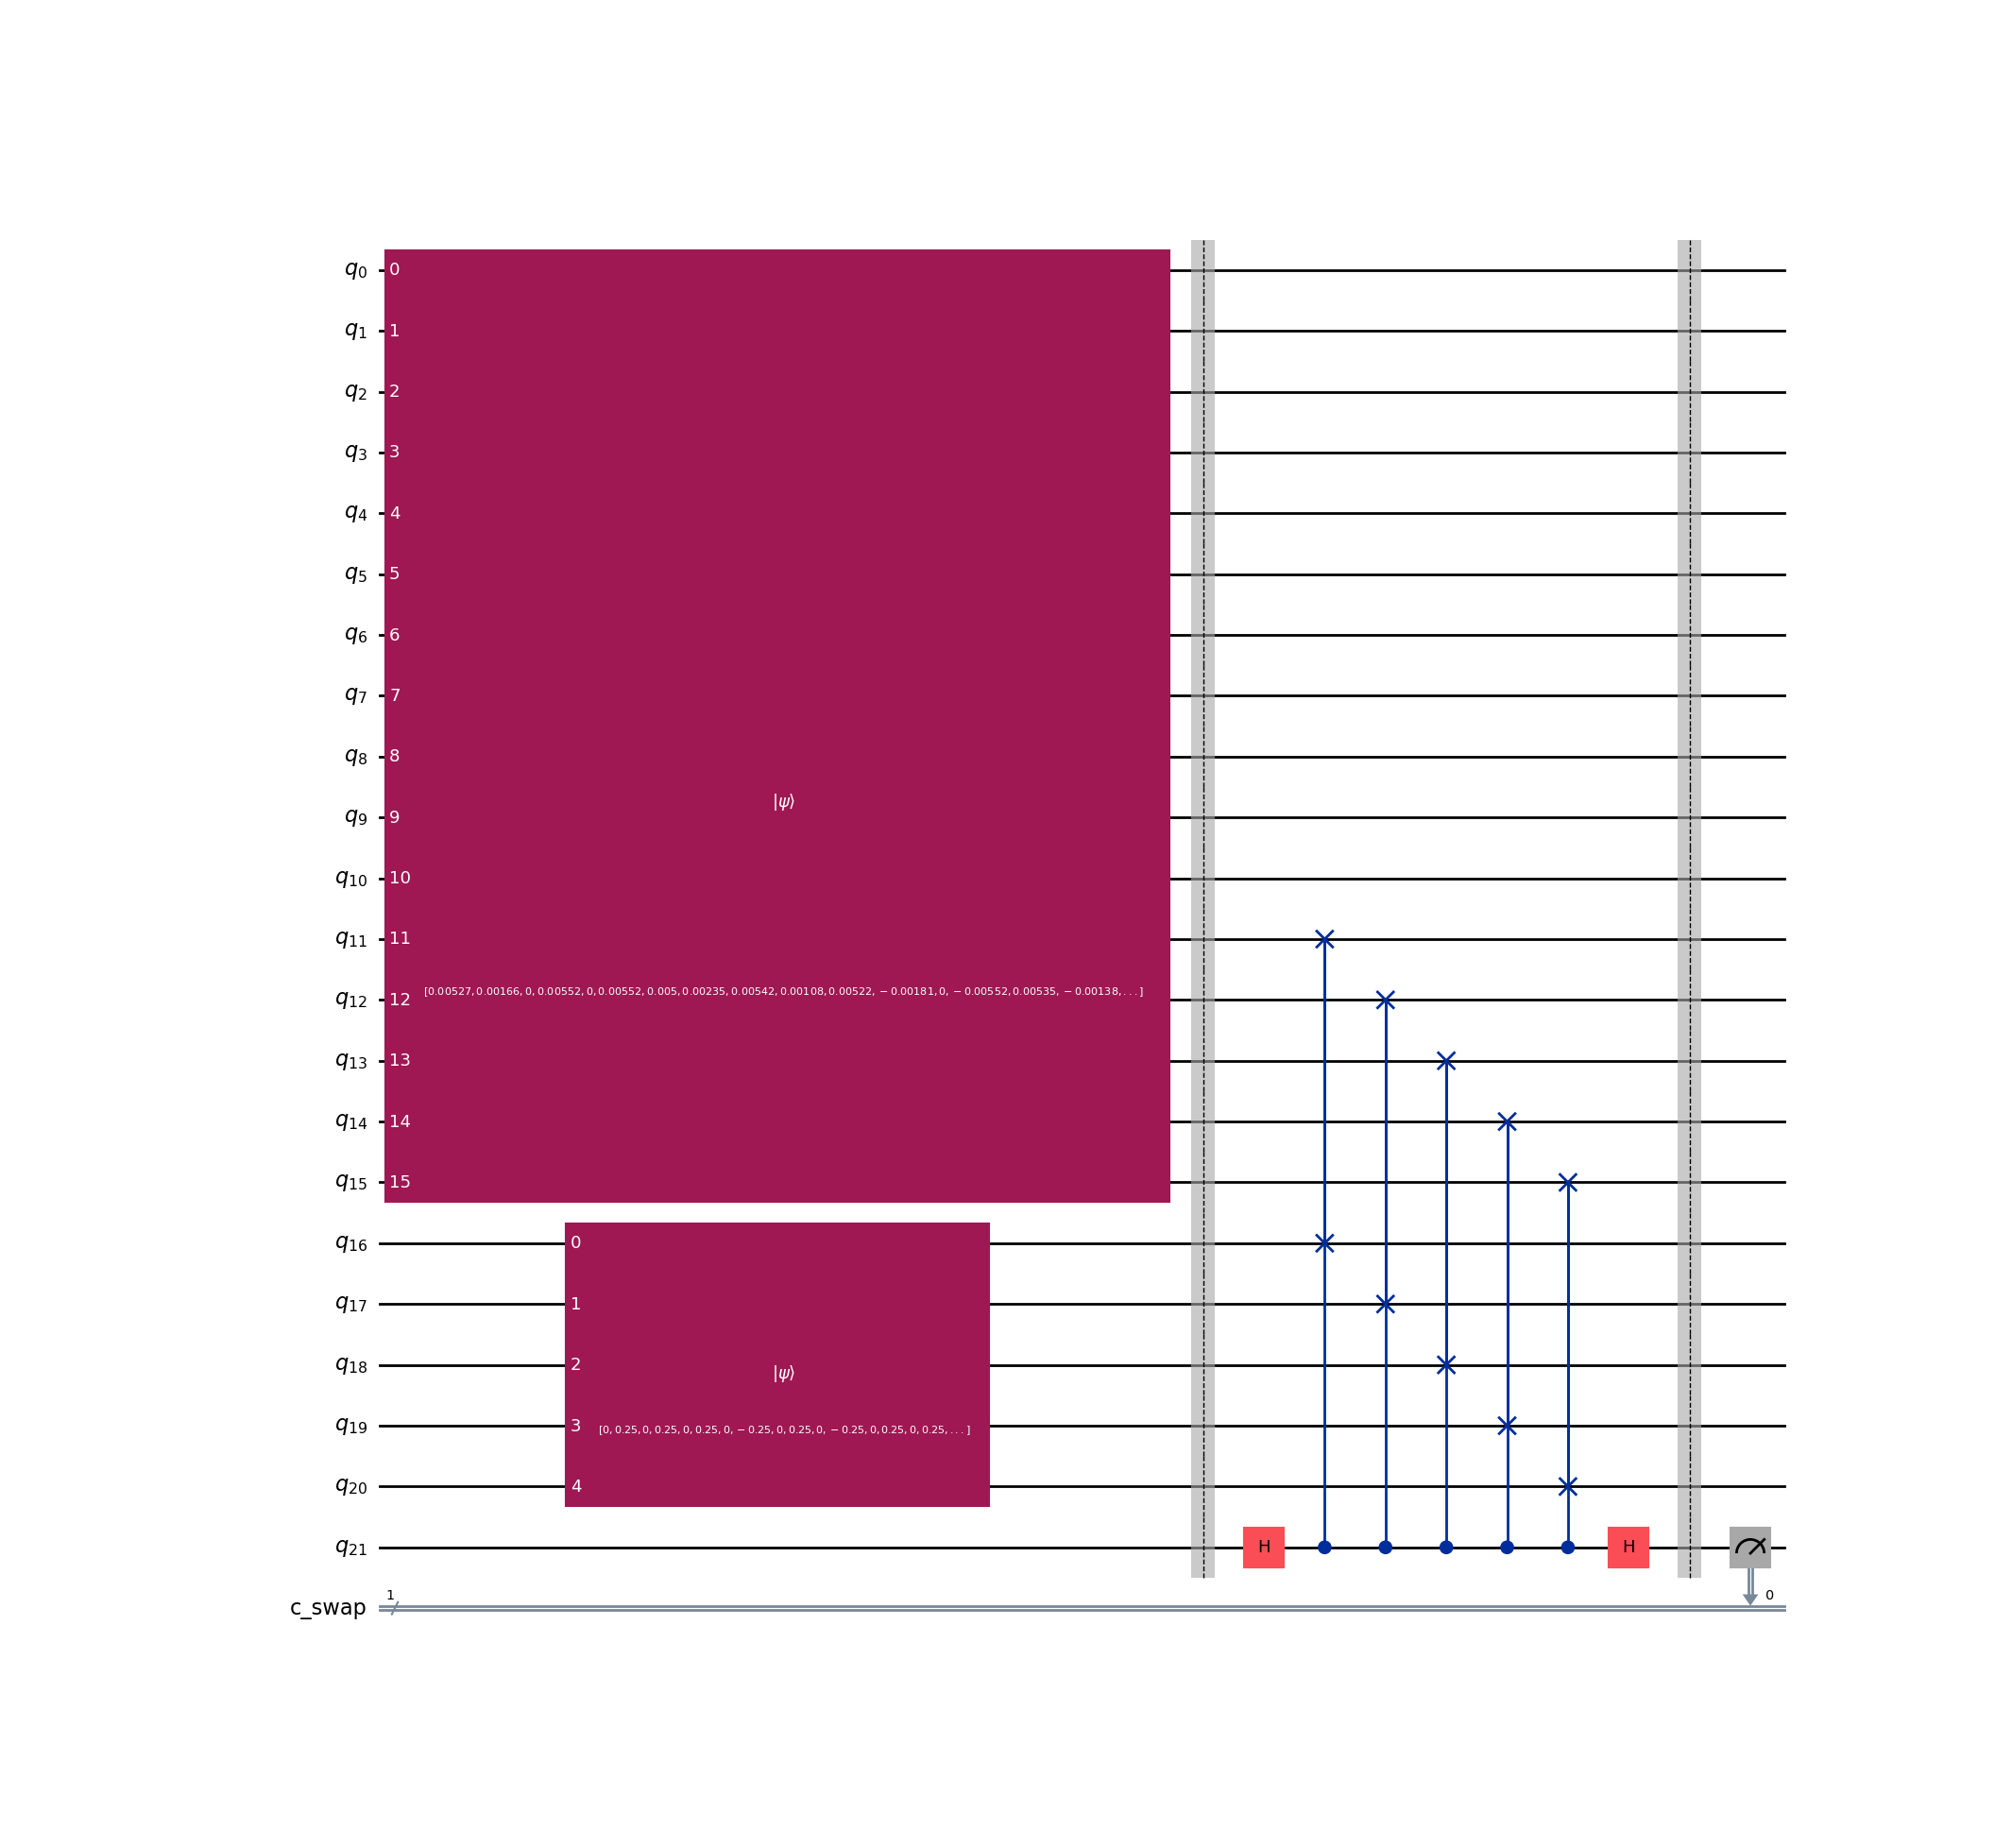

In [78]:
print(qc.draw(output='mpl'))